# MMA3001 Dataset 3 — Data Audit

This notebook audits the pork rasher object-detection dataset before model training.

The audit checks:
- dataset structure;
- class definitions;
- train/validation/test sizes;
- annotation consistency;
- class balance;
- duplicate or related images across splits;
- image and bounding-box quality.

In [11]:
from pathlib import Path
import yaml

dataset_root = Path(
    "/content/drive/MyDrive/MMA3001_Project/dataset/pork_rasher_v4"
)

yaml_path = dataset_root / "data.yaml"

print("Dataset root exists:", dataset_root.exists())
print("data.yaml exists:", yaml_path.exists())

with open(yaml_path, "r") as f:
    config = yaml.safe_load(f)

print("\nDataset configuration:")
print(config)

Dataset root exists: True
data.yaml exists: True

Dataset configuration:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 5, 'names': ['loose-meat', 'packaging-error', 'twisted-meat', 'unsealed', 'wrinkle'], 'roboflow': {'workspace': 'hello-2aqe0', 'project': 'pork-rasher-error-packaging', 'version': 4, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/hello-2aqe0/pork-rasher-error-packaging/dataset/4'}}


In [12]:
names = config["names"]

if isinstance(names, dict):
    class_names = {int(k): v for k, v in names.items()}
else:
    class_names = dict(enumerate(names))

print("Number of classes:", len(class_names))

print("\nClasses:")
for class_id, class_name in class_names.items():
    print(f"{class_id}: {class_name}")

Number of classes: 5

Classes:
0: loose-meat
1: packaging-error
2: twisted-meat
3: unsealed
4: wrinkle


## 2. Dataset Structure and File Counts

This section checks the number of images and annotation files in each split and identifies missing or unmatched files.

In [13]:
from collections import defaultdict

image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

split_summary = {}

for split in ["train", "valid", "test"]:
    images_dir = dataset_root / split / "images"
    labels_dir = dataset_root / split / "labels"

    image_files = sorted(
        p for p in images_dir.iterdir()
        if p.suffix.lower() in image_extensions
    )

    label_files = sorted(labels_dir.glob("*.txt"))

    image_stems = {p.stem for p in image_files}
    label_stems = {p.stem for p in label_files}

    missing_labels = image_stems - label_stems
    orphan_labels = label_stems - image_stems

    split_summary[split] = {
        "images": len(image_files),
        "labels": len(label_files),
        "missing_labels": len(missing_labels),
        "orphan_labels": len(orphan_labels),
    }

    print(f"\n{split.upper()}")
    print("Images:", len(image_files))
    print("Label files:", len(label_files))
    print("Images without labels:", len(missing_labels))
    print("Labels without images:", len(orphan_labels))


TRAIN
Images: 3349
Label files: 3349
Images without labels: 0
Labels without images: 0

VALID
Images: 120
Label files: 120
Images without labels: 0
Labels without images: 0

TEST
Images: 80
Label files: 80
Images without labels: 0
Labels without images: 0


In [14]:
import pandas as pd

summary_df = pd.DataFrame(split_summary).T
summary_df

,images,labels,missing_labels,orphan_labels
train,3349,3349,0,0
valid,120,120,0,0
test,80,80,0,0


## 3. Annotation Validation and Class Distribution

This section checks whether YOLO annotation files are valid and examines the distribution of defect classes across the training, validation and test sets.

In [15]:
from collections import Counter

box_counts = Counter()
image_counts = Counter()

invalid_annotations = []
empty_labels = []

for split in ["train", "valid", "test"]:
    labels_dir = dataset_root / split / "labels"

    for label_path in labels_dir.glob("*.txt"):
        text = label_path.read_text().strip()

        # Empty file = image with no labelled objects
        if not text:
            empty_labels.append((split, label_path.name))
            continue

        classes_in_image = set()

        for line_number, line in enumerate(text.splitlines(), start=1):
            parts = line.split()

            # YOLO format should be:
            # class_id x_center y_center width height
            if len(parts) != 5:
                invalid_annotations.append(
                    (split, label_path.name, line_number, "Wrong number of values")
                )
                continue

            try:
                class_id = int(parts[0])
                xc, yc, w, h = map(float, parts[1:])
            except ValueError:
                invalid_annotations.append(
                    (split, label_path.name, line_number, "Non-numeric value")
                )
                continue

            # Check class ID
            if class_id not in class_names:
                invalid_annotations.append(
                    (split, label_path.name, line_number, f"Invalid class ID {class_id}")
                )
                continue

            # Check normalized YOLO coordinates
            if not (
                0 <= xc <= 1
                and 0 <= yc <= 1
                and 0 < w <= 1
                and 0 < h <= 1
            ):
                invalid_annotations.append(
                    (split, label_path.name, line_number, "Invalid normalized box")
                )
                continue

            # Check that bounding box stays inside image
            if (
                xc - w / 2 < 0
                or xc + w / 2 > 1
                or yc - h / 2 < 0
                or yc + h / 2 > 1
            ):
                invalid_annotations.append(
                    (split, label_path.name, line_number, "Bounding box outside image")
                )
                continue

            box_counts[(split, class_id)] += 1
            classes_in_image.add(class_id)

        for class_id in classes_in_image:
            image_counts[(split, class_id)] += 1

print("Invalid annotations:", len(invalid_annotations))
print("Empty label files:", len(empty_labels))

if invalid_annotations:
    print("\nFirst 10 invalid annotations:")
    for item in invalid_annotations[:10]:
        print(item)

Invalid annotations: 0
Empty label files: 710


In [16]:
rows = []

for class_id, class_name in class_names.items():
    for split in ["train", "valid", "test"]:
        rows.append({
            "class_id": class_id,
            "class_name": class_name,
            "split": split,
            "images_with_class": image_counts[(split, class_id)],
            "bounding_boxes": box_counts[(split, class_id)],
        })

class_df = pd.DataFrame(rows)

class_df

,class_id,class_name,split,images_with_class,bounding_boxes
0,0,loose-meat,train,66,66
1,0,loose-meat,valid,3,3
2,0,loose-meat,test,2,3
3,1,packaging-error,train,1541,1712
4,1,packaging-error,valid,23,34
5,1,packaging-error,test,16,23
6,2,twisted-meat,train,69,72
7,2,twisted-meat,valid,3,3
8,2,twisted-meat,test,4,4
9,3,unsealed,train,1055,1055


In [17]:
class_pivot = class_df.pivot(
    index="class_name",
    columns="split",
    values="bounding_boxes"
)

class_pivot

split,test,train,valid
class_name,,,
loose-meat,3,66,3
packaging-error,23,1712,34
twisted-meat,4,72,3
unsealed,49,1055,81
wrinkle,0,18,0


## 4. Visual Inspection of Empty Labels
This section aims to visually inspect the files with empty labels to ensure they are true negatives.

In [18]:
from collections import Counter

empty_by_split = Counter(split for split, _ in empty_labels)

for split in ["train", "valid", "test"]:
    total = split_summary[split]["images"]
    empty = empty_by_split[split]

    print(
        f"{split}: {empty} empty labels / {total} images "
        f"({100 * empty / total:.1f}%)"
    )

train: 684 empty labels / 3349 images (20.4%)
valid: 14 empty labels / 120 images (11.7%)
test: 12 empty labels / 80 images (15.0%)


In [19]:
import random
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)

sample_empty = random.sample(
    empty_labels,
    min(12, len(empty_labels))
)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, (split, label_name) in zip(axes, sample_empty):

    image_stem = Path(label_name).stem
    images_dir = dataset_root / split / "images"

    image_path = None

    for ext in [".jpg", ".jpeg", ".png", ".webp"]:
        candidate = images_dir / f"{image_stem}{ext}"

        if candidate.exists():
            image_path = candidate
            break

    if image_path is None:
        ax.set_title("Image not found")
        ax.axis("off")
        continue

    with Image.open(image_path) as im:
        ax.imshow(im.convert("RGB"))

    ax.set_title(
        f"{split}\n{image_path.name[:30]}",
        fontsize=8
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 5. Duplicate and Cross-Split Source Check

Duplicate or closely related images across the training, validation and test sets can reduce the independence of model evaluation. This is especially important for an augmented image dataset, because different augmented versions of the same original photograph may appear as separate files.

Two checks are performed:

1. **Exact duplicate check**  
   SHA-256 hashes are calculated for every image. Images with identical hashes contain exactly the same file data.

2. **Possible shared-source check**  
   Roboflow filenames are inspected using the portion of the filename before `.rf.` as a possible original-image identifier. If the same source identifier appears in more than one split, the images may be augmented versions derived from the same original photograph.

The second check is treated as a screening method rather than definitive proof of duplication. Any detected cross-split source groups should be investigated before changing the dataset.

### Filename Structure

The Roboflow-exported images follow a naming pattern such as:

`frame_with_red_256_jpg.rf.4ce06899c311a164da359ea6d93a319f.jpg`

The portion before `.rf.` identifies the apparent source image, while the portion after `.rf.` is a Roboflow-generated identifier for the exported image.

For example:

- Source identifier: `frame_with_red_256_jpg`
- Roboflow identifier: `4ce06899c311a164da359ea6d93a319f`

Images with the same source identifier but different Roboflow identifiers may represent different processed or augmented versions of the same original image. Therefore, source identifiers are compared across the training, validation and test sets to screen for possible cross-split leakage.

In [20]:
from collections import defaultdict

source_groups = defaultdict(list)

for split in ["train", "valid", "test"]:
    images_dir = dataset_root / split / "images"

    for image_path in images_dir.iterdir():
        if image_path.suffix.lower() not in image_extensions:
            continue

        # Everything before ".rf." is treated as the source identifier
        source_id = image_path.name.split(".rf.", 1)[0]

        source_groups[source_id].append({
            "split": split,
            "filename": image_path.name
        })

# Keep only sources appearing in more than one dataset split
cross_split_sources = {}

for source_id, items in source_groups.items():

    splits = {item["split"] for item in items}

    if len(splits) > 1:
        cross_split_sources[source_id] = items

print(
    "Possible shared source images across splits:",
    len(cross_split_sources)
)

for source_id, items in list(cross_split_sources.items())[:10]:
    print(f"\nSource: {source_id}")

    for item in items:
        print(
            f"  {item['split']}: "
            f"{item['filename']}"
        )

Possible shared source images across splits: 13

Source: frame_with_red_7508_jpg
  train: frame_with_red_7508_jpg.rf.481d6ca5af66bd1daee9d6a3a953d30a.jpg
  train: frame_with_red_7508_jpg.rf.1a0c6b812ef87a67ff83ace40ff7a97c.jpg
  train: frame_with_red_7508_jpg.rf.01b3fd78f0066c71912ea5c670872197.jpg
  valid: frame_with_red_7508_jpg.rf.38e5d3b2ef3e41f34b9cc671f705d592.jpg

Source: frame_with_red_7510_jpg
  train: frame_with_red_7510_jpg.rf.2b335a6abf65d6a0b8d1303aa2b6f22e.jpg
  train: frame_with_red_7510_jpg.rf.5d4f6ad5878928328b4c9c479dbfb94f.jpg
  train: frame_with_red_7510_jpg.rf.6c62e4430c0d8f4a4a3a1625ff40d0ee.jpg
  test: frame_with_red_7510_jpg.rf.ab32fc359f85d0aa457f0c8cf746ac00.jpg

Source: frame_with_red_7555_jpg
  train: frame_with_red_7555_jpg.rf.0db280827b7de8cde65aaaaae278f756.jpg
  train: frame_with_red_7555_jpg.rf.893f948e06df3755bf9ff11d58e19004.jpg
  train: frame_with_red_7555_jpg.rf.f689119f39f063b77c8e0c4e5b139d62.jpg
  valid: frame_with_red_7555_jpg.rf.bb6e12790123e5c

### Visual Check of Possible Shared-Source Images

The filename-based check identified several source identifiers that appear in more than one dataset split. To confirm whether these files are actually different versions of the same original image, selected source groups are displayed side by side.

If the images show the same tray, camera viewpoint and defect arrangement, they are treated as related observations from the same original source and should not be split across training, validation and test sets.

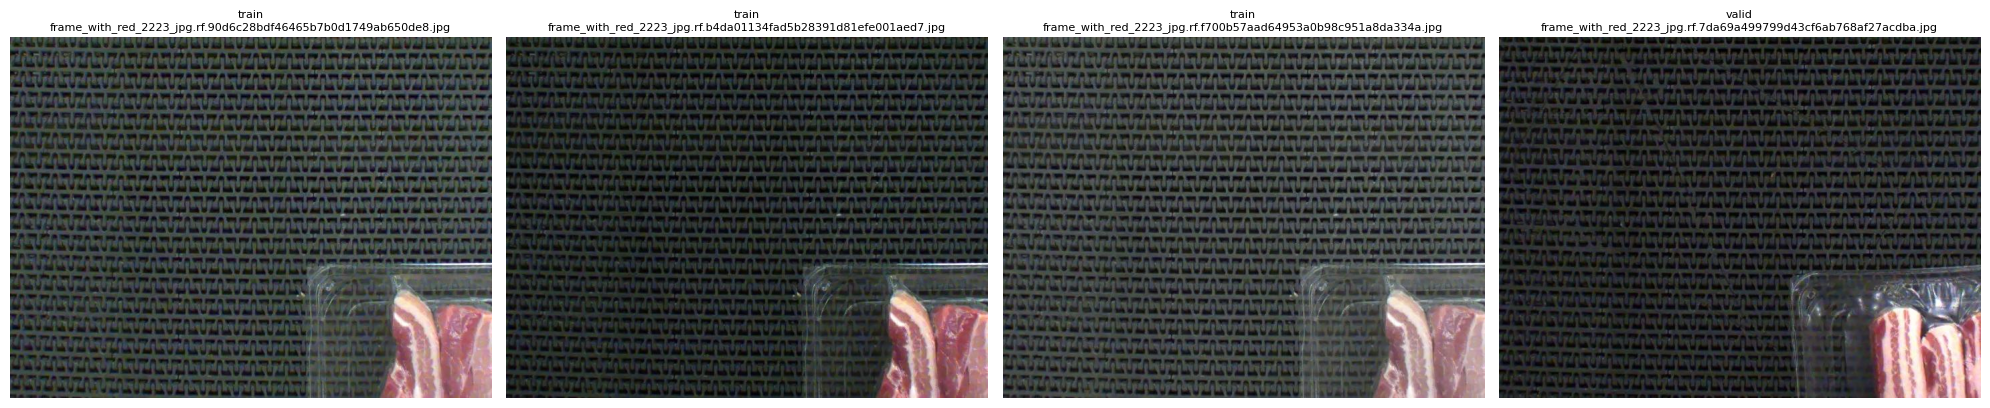

In [24]:
import matplotlib.pyplot as plt
from PIL import Image

# Pick one flagged source
source_to_check = "frame_with_red_2223_jpg"

items = cross_split_sources[source_to_check]

fig, axes = plt.subplots(
    1,
    len(items),
    figsize=(5 * len(items), 5)
)

if len(items) == 1:
    axes = [axes]

for ax, item in zip(axes, items):
    split = item["split"]
    filename = item["filename"]

    image_path = dataset_root / split / "images" / filename

    with Image.open(image_path) as im:
        ax.imshow(im.convert("RGB"))

    ax.set_title(
        f"{split}\n{filename}",
        fontsize=8
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

### Duplicate and Shared-Source Check Findings

No confirmed cross-split duplicate leakage was identified.

The filename-based screening initially detected 13 possible source identifiers appearing across multiple dataset splits. However, visual inspection showed that matching filename prefixes did not always correspond to the same underlying image.

The genuinely related or augmented images observed were contained within the training set. This is acceptable because augmentation is intended to increase training diversity, provided that validation and test images remain independent.

Therefore, the original train, validation and test splits are retained unchanged at this stage.

## 6. Minority-Class Investigation: Wrinkle

The `wrinkle` class contains training annotations but no validation or test annotations.

Before modifying the dataset split, the number of unique source images containing wrinkles is investigated. Augmented versions derived from the same original image must remain within the same split to avoid cross-split leakage.

In [25]:
wrinkle_id = 4

wrinkle_images = []

for split in ["train", "valid", "test"]:
    labels_dir = dataset_root / split / "labels"

    for label_path in labels_dir.glob("*.txt"):
        text = label_path.read_text().strip()

        if not text:
            continue

        class_ids = [
            int(line.split()[0])
            for line in text.splitlines()
        ]

        if wrinkle_id in class_ids:
            image_name = label_path.stem

            wrinkle_images.append({
                "split": split,
                "stem": image_name,
                "source_id": image_name.split(".rf.", 1)[0]
            })

print("Images containing wrinkle:", len(wrinkle_images))

unique_sources = sorted(
    {item["source_id"] for item in wrinkle_images}
)

print("Unique wrinkle source images:", len(unique_sources))

print("\nSources:")
for source in unique_sources:
    related = [
        item for item in wrinkle_images
        if item["source_id"] == source
    ]

    print(f"\n{source}")
    for item in related:
        print(" ", item["split"], item["stem"])

Images containing wrinkle: 18
Unique wrinkle source images: 6

Sources:

frame_with_red_10412_jpg
  train frame_with_red_10412_jpg.rf.d36e4f2ccb037a5fd93b04caa1ba410f
  train frame_with_red_10412_jpg.rf.ace4f43621b506ccb7bb9ac96c4da901
  train frame_with_red_10412_jpg.rf.bbbb19fcabddc01072621bc62f53663d

frame_with_red_10436_jpg
  train frame_with_red_10436_jpg.rf.9727b77dfadda98917c588f8b3f293d1
  train frame_with_red_10436_jpg.rf.02986531660d35f41ed781b286e6162b
  train frame_with_red_10436_jpg.rf.5f6b09b72388f2a9b11e89921ecac3d3

frame_with_red_10465_jpg
  train frame_with_red_10465_jpg.rf.eb7d6ac5b6b71b3722832e87f41cd2f6
  train frame_with_red_10465_jpg.rf.800ed5e3f0775757ce0a2da1bbb795e1
  train frame_with_red_10465_jpg.rf.c9b478755d959507cef60b582c82f071

frame_with_red_10498_jpg
  train frame_with_red_10498_jpg.rf.5a9f4cd01cff340d1303953a5cf22a21
  train frame_with_red_10498_jpg.rf.50d275e40bbb49cab8508344bc442e48
  train frame_with_red_10498_jpg.rf.46f961e0842f830cde8d54fb85ecf



The wrinkle class contains 18 annotated images derived from only 6 unique source images, with three augmented versions per source.

To provide independent wrinkle examples for model validation and testing, the dataset may be reorganised by source rather than by individual augmented image. Before changing the split, the other defect classes present in each wrinkle source are examined so that moving a source does not unintentionally remove important examples of another minority class.

In [26]:
from collections import Counter, defaultdict

wrinkle_source_classes = defaultdict(Counter)

for item in wrinkle_images:
    split = item["split"]
    stem = item["stem"]
    source_id = item["source_id"]

    label_path = dataset_root / split / "labels" / f"{stem}.txt"

    text = label_path.read_text().strip()

    if not text:
        continue

    for line in text.splitlines():
        class_id = int(line.split()[0])
        wrinkle_source_classes[source_id][class_id] += 1


for source_id in unique_sources:
    print(f"\n{source_id}")

    counts = wrinkle_source_classes[source_id]

    for class_id, count in sorted(counts.items()):
        print(
            f"  {class_names[class_id]}: {count} boxes"
        )


frame_with_red_10412_jpg
  wrinkle: 3 boxes

frame_with_red_10436_jpg
  wrinkle: 3 boxes

frame_with_red_10465_jpg
  wrinkle: 3 boxes

frame_with_red_10498_jpg
  wrinkle: 3 boxes

frame_with_red_10552_jpg
  wrinkle: 3 boxes

frame_with_red_8644_jpg
  wrinkle: 3 boxes


The `wrinkle` class is represented by 18 annotated images derived from only 6 unique source images. All six source groups contain only wrinkle annotations.

The supplied dataset contains no wrinkle examples in the validation or test sets, preventing independent evaluation of this class.

A source-level split is therefore used:

- 4 unique wrinkle sources remain in training;
- 1 unique wrinkle source is assigned to validation;
- 1 unique wrinkle source is assigned to testing.

All augmented versions belonging to the same source remain together in one split to avoid leakage.

Validation and test sources are selected using a fixed random seed to make the process reproducible and avoid manually selecting favourable examples.

In [27]:
import random

wrinkle_sources = sorted(unique_sources)

random.seed(42)

validation_source, test_source = random.sample(wrinkle_sources, 2)

training_sources = [
    source for source in wrinkle_sources
    if source not in {validation_source, test_source}
]

print("Training sources:")
for source in training_sources:
    print(" ", source)

print("\nValidation source:")
print(" ", validation_source)

print("\nTest source:")
print(" ", test_source)

Training sources:
  frame_with_red_10436_jpg
  frame_with_red_10465_jpg
  frame_with_red_10498_jpg
  frame_with_red_10552_jpg

Validation source:
  frame_with_red_8644_jpg

Test source:
  frame_with_red_10412_jpg


## 9. Creation of Cleaned Dataset

The original Roboflow dataset is preserved unchanged.

A separate cleaned dataset is created for model development. The selected wrinkle source groups are moved from the training split into validation and testing while keeping all augmented versions of each source together.

In [28]:
import shutil
from pathlib import Path

original_root = Path(
    "/content/drive/MyDrive/MMA3001_Project/dataset/pork_rasher_v4"
)

clean_root = Path(
    "/content/drive/MyDrive/MMA3001_Project/dataset/pork_rasher_v4_clean"
)

if clean_root.exists():
    raise FileExistsError(
        f"{clean_root} already exists. "
        "Delete it manually only if you intentionally want to recreate it."
    )

shutil.copytree(original_root, clean_root)

print("Clean dataset copy created:")
print(clean_root)

Clean dataset copy created:
/content/drive/MyDrive/MMA3001_Project/dataset/pork_rasher_v4_clean


In [29]:
def move_source(source_id, destination_split):
    source_images = clean_root / "train" / "images"
    source_labels = clean_root / "train" / "labels"

    destination_images = clean_root / destination_split / "images"
    destination_labels = clean_root / destination_split / "labels"

    matching_images = [
        p for p in source_images.iterdir()
        if p.name.startswith(source_id + ".rf.")
    ]

    print(
        f"\nMoving {source_id} -> {destination_split} "
        f"({len(matching_images)} images)"
    )

    for image_path in matching_images:
        label_path = source_labels / f"{image_path.stem}.txt"

        shutil.move(
            str(image_path),
            str(destination_images / image_path.name)
        )

        shutil.move(
            str(label_path),
            str(destination_labels / label_path.name)
        )


move_source(validation_source, "valid")
move_source(test_source, "test")


Moving frame_with_red_8644_jpg -> valid (3 images)

Moving frame_with_red_10412_jpg -> test (3 images)


In [30]:
for split in ["train", "valid", "test"]:
    images_dir = clean_root / split / "images"
    labels_dir = clean_root / split / "labels"

    images = list(images_dir.glob("*.jpg"))
    labels = list(labels_dir.glob("*.txt"))

    wrinkle_images_count = 0
    wrinkle_boxes_count = 0
    wrinkle_source_ids = set()

    for label_path in labels:
        text = label_path.read_text().strip()

        if not text:
            continue

        class_ids = [
            int(line.split()[0])
            for line in text.splitlines()
        ]

        if wrinkle_id in class_ids:
            wrinkle_images_count += 1
            wrinkle_boxes_count += class_ids.count(wrinkle_id)
            wrinkle_source_ids.add(
                label_path.stem.split(".rf.", 1)[0]
            )

    print(f"\n{split.upper()}")
    print("Total images:", len(images))
    print("Wrinkle images:", wrinkle_images_count)
    print("Wrinkle boxes:", wrinkle_boxes_count)
    print("Unique wrinkle sources:", len(wrinkle_source_ids))


TRAIN
Total images: 3343
Wrinkle images: 12
Wrinkle boxes: 12
Unique wrinkle sources: 4

VALID
Total images: 123
Wrinkle images: 3
Wrinkle boxes: 3
Unique wrinkle sources: 1

TEST
Total images: 83
Wrinkle images: 3
Wrinkle boxes: 3
Unique wrinkle sources: 1
